In [1]:
%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.8 MB/s eta 0:00:00


In [2]:
!pip install ctgan

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer
from sdv.evaluation.single_table import run_diagnostic, evaluate_quality, get_column_plot, get_column_pair_plot

In [7]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FINALFINAL.csv', sep=';', encoding='latin1')

data.head()

,CASEID,FUELTYPE,WEATHER,SURFCOND,VIN,DVTOTAL,ROLLOVER,SPEEDLIMIT,BODYTYPE,PASSENGERS,BELTED_PASSENGERS,GAD1,AIRBAG_DEPLOYED,FIRE
0,2400023,gasoline,clear,dry,1N6AA1ED2MN5,25,no rollover,56,pickup/light truck,2,2,Front,Deployed,missing
1,2400024,gasoline,rain,wet,WDDSJ4EBXGN3,25,no rollover,80,passenger car,2,2,Front,Deployed,missing
2,2400030,gasoline,snow,snow,5FNYF6H03LB0,999,rollover,129,SUV,5,5,Right Side,Deployed,missing
3,2400035,gasoline,clear,dry,5TFCZ5AN5HX1,999,no rollover,89,pickup/light truck,1,1,Front,Deployed,missing
4,2400042,gasoline,rain,wet,1N4AA6AP4GC4,999,no rollover,113,passenger car,1,0,Unknown,Unknown,missing


In [8]:
data.columns

Index(['CASEID', 'FUELTYPE', 'WEATHER', 'SURFCOND', 'VIN', 'DVTOTAL',
       'ROLLOVER', 'SPEEDLIMIT', 'BODYTYPE', 'PASSENGERS', 'BELTED_PASSENGERS',
       'GAD1', 'AIRBAG_DEPLOYED', 'FIRE'],
      dtype='object')

In [9]:
data.shape


(736, 14)

In [10]:
import numpy as np
data['DVTOTAL'] = pd.to_numeric(data['DVTOTAL'], errors='coerce')
data['DVTOTAL'] = data['DVTOTAL'].replace(999, np.nan)
observed_dvtotal = data['DVTOTAL'].dropna()
data.loc[data['DVTOTAL'].isna(), 'DVTOTAL'] = observed_dvtotal.sample(data['DVTOTAL'].isna().sum(), replace=True).values

data['SPEEDLIMIT'] = pd.to_numeric(data['SPEEDLIMIT'], errors='coerce')
data['SPEEDLIMIT'] = data['SPEEDLIMIT'].replace(999, np.nan)
observed_speedlimit = data['SPEEDLIMIT'].dropna()
data.loc[data['SPEEDLIMIT'].isna(), 'SPEEDLIMIT'] = observed_speedlimit.sample(data['SPEEDLIMIT'].isna().sum(), replace=True).values

In [11]:
data = data.drop(columns=['CASEID'])
data.head()

,FUELTYPE,WEATHER,SURFCOND,VIN,DVTOTAL,ROLLOVER,SPEEDLIMIT,BODYTYPE,PASSENGERS,BELTED_PASSENGERS,GAD1,AIRBAG_DEPLOYED,FIRE
0,gasoline,clear,dry,1N6AA1ED2MN5,25.0,no rollover,56.0,pickup/light truck,2,2,Front,Deployed,missing
1,gasoline,rain,wet,WDDSJ4EBXGN3,25.0,no rollover,80.0,passenger car,2,2,Front,Deployed,missing
2,gasoline,snow,snow,5FNYF6H03LB0,63.0,rollover,129.0,SUV,5,5,Right Side,Deployed,missing
3,gasoline,clear,dry,5TFCZ5AN5HX1,24.0,no rollover,89.0,pickup/light truck,1,1,Front,Deployed,missing
4,gasoline,rain,wet,1N4AA6AP4GC4,24.0,no rollover,113.0,passenger car,1,0,Unknown,Unknown,missing


In [12]:
metadata = Metadata.detect_from_dataframe(data=data)
metadata.update_column(column_name='FUELTYPE', table_name='table', sdtype='categorical')
metadata.update_column(column_name='WEATHER', table_name='table', sdtype='categorical')
metadata.update_column(column_name='SURFCOND', table_name='table', sdtype='categorical')
metadata.update_column(column_name='DVTOTAL', table_name='table', sdtype='numerical')
metadata.update_column(column_name='ROLLOVER', table_name='table', sdtype='categorical')
metadata.update_column(column_name='SPEEDLIMIT', table_name='table', sdtype='numerical')
metadata.update_column(column_name='BODYTYPE', table_name='table', sdtype='categorical')
metadata.update_column(column_name='PASSENGERS', table_name='table', sdtype='categorical')
metadata.update_column(column_name='BELTED_PASSENGERS', table_name='table', sdtype='categorical')
metadata.update_column(column_name='GAD1', table_name='table', sdtype='categorical')
metadata.update_column(column_name='AIRBAG_DEPLOYED', table_name='table', sdtype='categorical')
metadata.update_column(column_name='FIRE', table_name='table', sdtype='categorical')
metadata

{
    "tables": {
        "table": {
            "columns": {
                "FUELTYPE": {
                    "sdtype": "categorical"
                },
                "WEATHER": {
                    "sdtype": "categorical"
                },
                "SURFCOND": {
                    "sdtype": "categorical"
                },
                "VIN": {
                    "pii": true,
                    "sdtype": "vin"
                },
                "DVTOTAL": {
                    "sdtype": "numerical"
                },
                "ROLLOVER": {
                    "sdtype": "categorical"
                },
                "SPEEDLIMIT": {
                    "sdtype": "numerical"
                },
                "BODYTYPE": {
                    "sdtype": "categorical"
                },
                "PASSENGERS": {
                    "sdtype": "categorical"
                },
                "BELTED_PASSENGERS": {
                    "sdtype": "categorical"


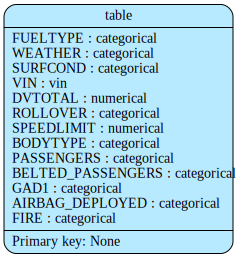

In [13]:
metadata.visualize()

In [14]:
metadata.validate_table(data)

In [18]:
synthesizer = CTGANSynthesizer(
    metadata=metadata,
    epochs=300,
    verbose=True
)

In [19]:
synthesizer.fit(data)
synthetic_data = synthesizer.sample(num_rows=len(data))

Gen. (-00.12) | Discrim. (+00.06): 100%|██████████| 300/300 [00:30<00:00,  9.98it/s]


In [20]:
columns = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'VIN',
    'DVTOTAL',
    'ROLLOVER',
    'SPEEDLIMIT',
    'BODYTYPE',
    'PASSENGERS',
    'BELTED_PASSENGERS',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'
]

for col in columns:
    print(f'\n--- {col} ---')
    display(
        pd.DataFrame({
            'Real': data[col].value_counts(),
            'Synthetic': synthetic_data[col].value_counts()
        }).fillna(0)
    )


--- FUELTYPE ---


,Real,Synthetic
FUELTYPE,,
gasoline,693,682
gasoline/ethanol,21,25
diesel,15,16
gasoline/lithium (elbil),7,13



--- WEATHER ---


,Real,Synthetic
WEATHER,,
clear,564,555
rain,68,68
cloudy,64,54
snow,20,34
unknown,20,25



--- SURFCOND ---


...

,Real,Synthetic
GAD1,,
Back/Truck Back,8,7
Front,573,534
Left Side,36,46
Noncollision,6,15
Right Side,37,40
Top,53,58
Undercarriage,11,15
Unknown,12,21



--- AIRBAG_DEPLOYED ---


,Real,Synthetic
AIRBAG_DEPLOYED,,
Deployed,375,382
Not deployed/not available,254,245
Unknown,107,109



--- FIRE ---


,Real,Synthetic
FIRE,,
fire,2,11
missing,731,716
no fire,3,9


In [21]:
synthetic_data.to_csv('/content/drive/MyDrive/Colab Notebooks/synthetic_FINALFINAL_CTGANSYN.csv', index=False, sep=';')

In [22]:
diagnostic = run_diagnostic(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 950.67it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 282.05it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [23]:
diagnostic.get_score()

np.float64(1.0)

In [24]:
quality_report = evaluate_quality(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 565.72it/s]|
Column Shapes Score: 92.53%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 181.16it/s]|
Column Pair Trends Score: 67.53%

Overall Score (Average): 80.03%



In [25]:
quality_report.get_score()

np.float64(0.8003025587313106)

In [26]:
diagnostic.get_details(property_name='Data Validity')
quality_report.get_details(property_name='Column Shapes')

,Column,Metric,Score
0,FUELTYPE,TVComplement,0.985054
1,WEATHER,TVComplement,0.974185
2,SURFCOND,TVComplement,0.974185
3,DVTOTAL,KSComplement,0.785326
4,ROLLOVER,TVComplement,0.970109
5,SPEEDLIMIT,KSComplement,0.677989
6,BODYTYPE,TVComplement,0.936881
7,PASSENGERS,TVComplement,0.949728
8,BELTED_PASSENGERS,TVComplement,0.937500
9,GAD1,TVComplement,0.945652


In [27]:
quality_report.get_details(property_name='Column Shapes')

,Column,Metric,Score
0,FUELTYPE,TVComplement,0.985054
1,WEATHER,TVComplement,0.974185
2,SURFCOND,TVComplement,0.974185
3,DVTOTAL,KSComplement,0.785326
4,ROLLOVER,TVComplement,0.970109
5,SPEEDLIMIT,KSComplement,0.677989
6,BODYTYPE,TVComplement,0.936881
7,PASSENGERS,TVComplement,0.949728
8,BELTED_PASSENGERS,TVComplement,0.937500
9,GAD1,TVComplement,0.945652


In [28]:
quality_report = evaluate_quality(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 414.67it/s]|
Column Shapes Score: 92.53%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 202.77it/s]|
Column Pair Trends Score: 67.53%

Overall Score (Average): 80.03%



In [29]:
diagnostic.get_details(property_name='Data Validity')

,Column,Metric,Score
0,FUELTYPE,CategoryAdherence,1.0
1,WEATHER,CategoryAdherence,1.0
2,SURFCOND,CategoryAdherence,1.0
3,DVTOTAL,BoundaryAdherence,1.0
4,ROLLOVER,CategoryAdherence,1.0
5,SPEEDLIMIT,BoundaryAdherence,1.0
6,BODYTYPE,CategoryAdherence,1.0
7,PASSENGERS,CategoryAdherence,1.0
8,BELTED_PASSENGERS,CategoryAdherence,1.0
9,GAD1,CategoryAdherence,1.0


In [30]:
quality_report.get_details(property_name='Column Shapes')

,Column,Metric,Score
0,FUELTYPE,TVComplement,0.985054
1,WEATHER,TVComplement,0.974185
2,SURFCOND,TVComplement,0.974185
3,DVTOTAL,KSComplement,0.785326
4,ROLLOVER,TVComplement,0.970109
5,SPEEDLIMIT,KSComplement,0.677989
6,BODYTYPE,TVComplement,0.936881
7,PASSENGERS,TVComplement,0.949728
8,BELTED_PASSENGERS,TVComplement,0.937500
9,GAD1,TVComplement,0.945652


In [31]:
quality_report.get_details(property_name='Column Pair Trends')

,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,FUELTYPE,WEATHER,ContingencySimilarity,NaN,NaN,NaN,0.106304,False
1,FUELTYPE,SURFCOND,ContingencySimilarity,NaN,NaN,NaN,0.125589,False
2,FUELTYPE,DVTOTAL,ContingencySimilarity,NaN,NaN,NaN,0.161102,False
3,FUELTYPE,ROLLOVER,ContingencySimilarity,NaN,NaN,NaN,0.052934,False
4,FUELTYPE,SPEEDLIMIT,ContingencySimilarity,NaN,NaN,NaN,0.145974,False
...,...,...,...,...,...,...,...,...
61,BELTED_PASSENGERS,AIRBAG_DEPLOYED,ContingencySimilarity,NaN,NaN,NaN,0.275610,False
62,BELTED_PASSENGERS,FIRE,ContingencySimilarity,NaN,NaN,NaN,0.035446,False
63,GAD1,AIRBAG_DEPLOYED,ContingencySimilarity,NaN,NaN,NaN,0.256907,False
64,GAD1,FIRE,ContingencySimilarity,NaN,NaN,NaN,0.176186,False


In [32]:
save_path = "/content/drive/MyDrive/Colab Notebooks/results/plots_CTGANSynthesizer"

In [34]:

columns = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'DVTOTAL',
    'ROLLOVER',
    'SPEEDLIMIT',
    'BODYTYPE',
    'PASSENGERS',
    'BELTED_PASSENGERS',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'
]

for col in columns:
    fig = get_column_plot(
        real_data=data,
        synthetic_data=synthetic_data,
        column_name=col,
        metadata=metadata
    )



    fig.update_layout(
        template='plotly_white',
        title=dict(
            text=f'Real vs Synthetic: {col}',
            x=0.5,
            font=dict(size=22)
        ),
        width=950,
        height=550,
        font=dict(size=14),
        legend=dict(
            title='',
            orientation='h',
            y=1.08,
            x=0.5,
            xanchor='center'
        ),
        margin=dict(l=60, r=40, t=90, b=60)
    )

    fig.update_yaxes(
        title='Count',
        gridcolor='rgba(0,0,0,0.08)'
    )

    fig.show()

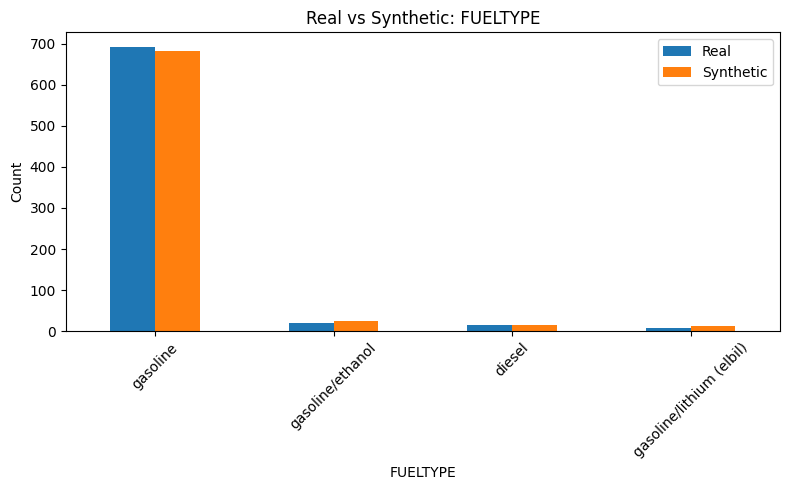

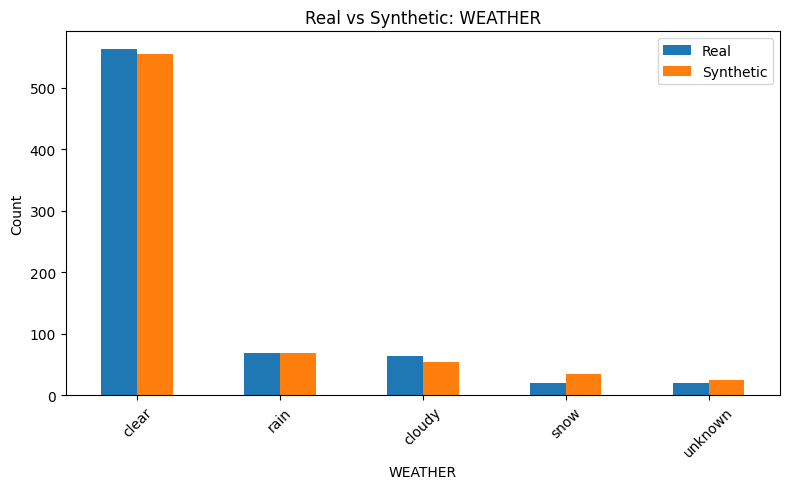

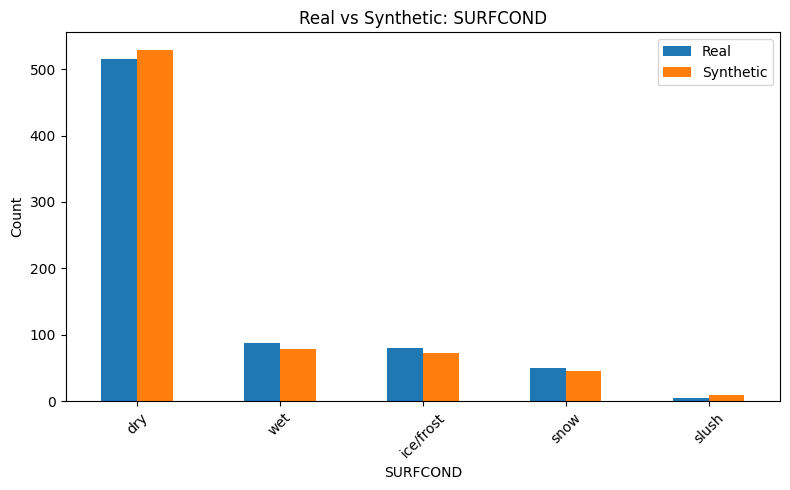

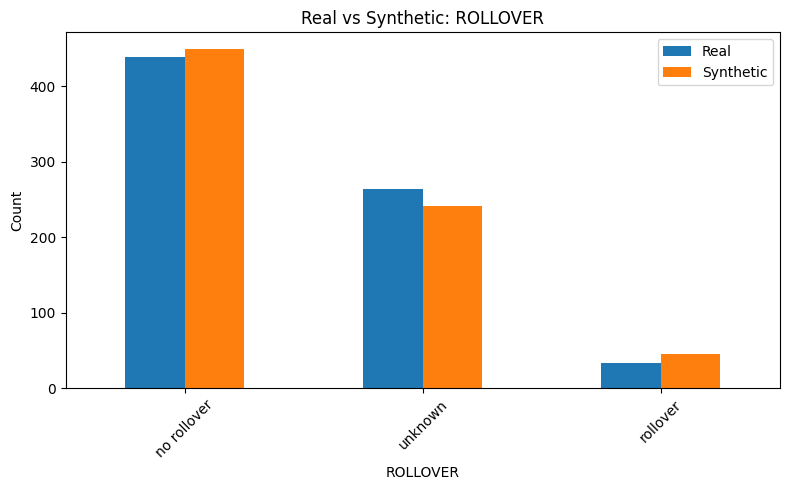

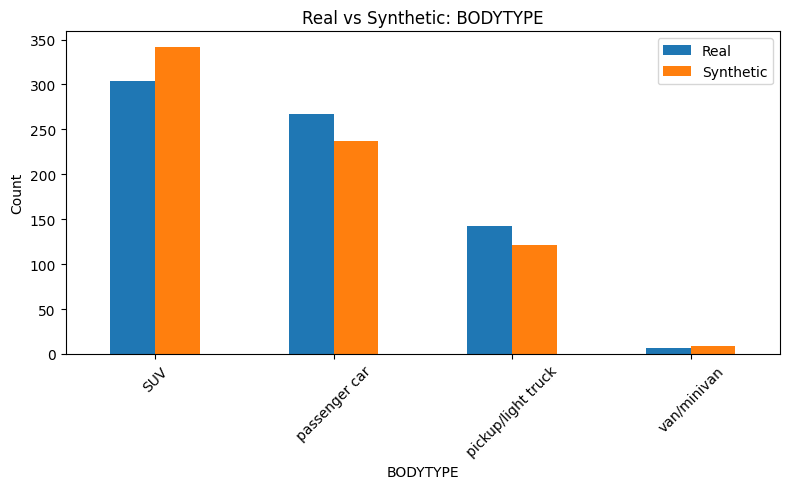

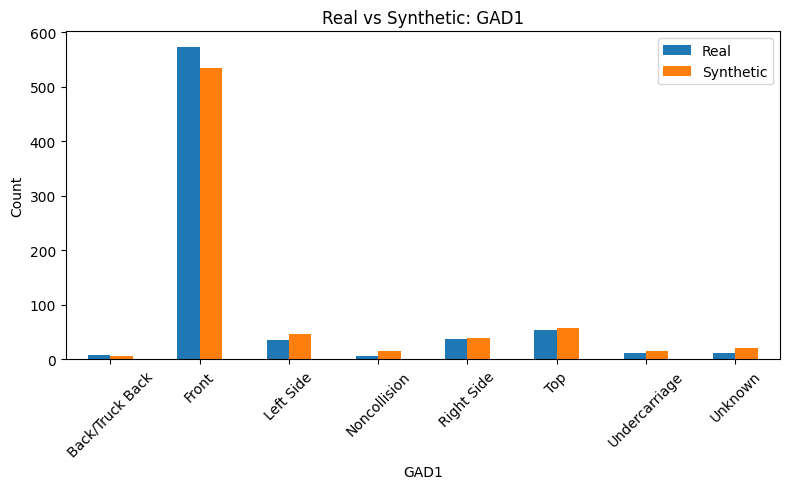

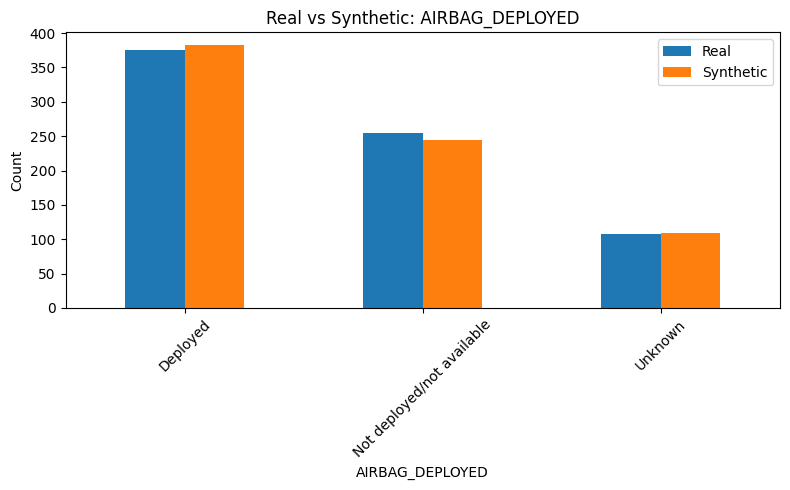

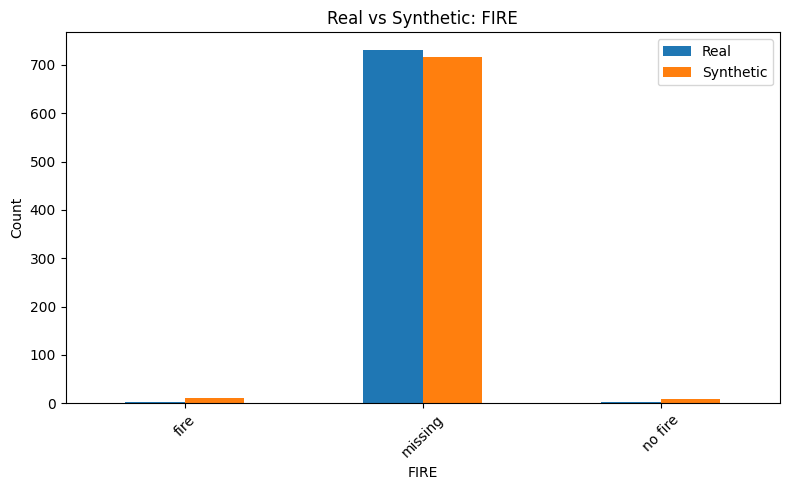

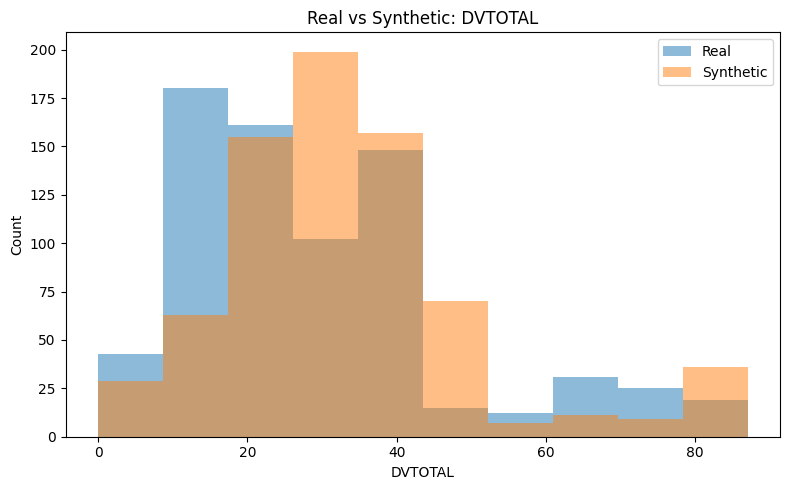

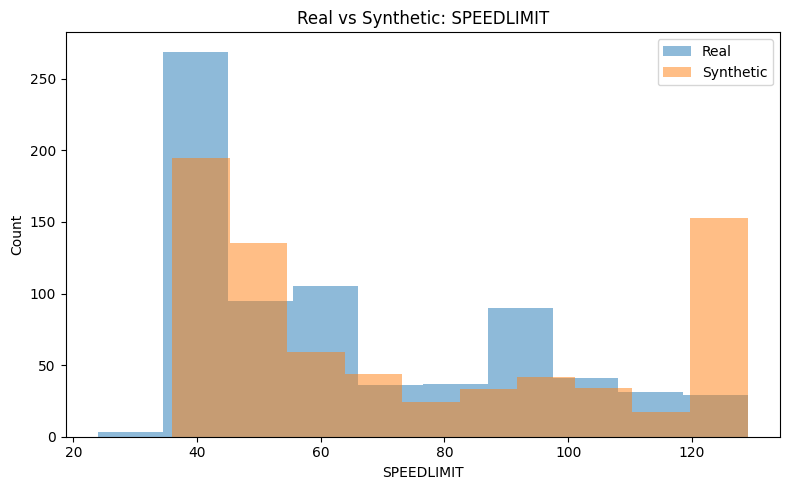

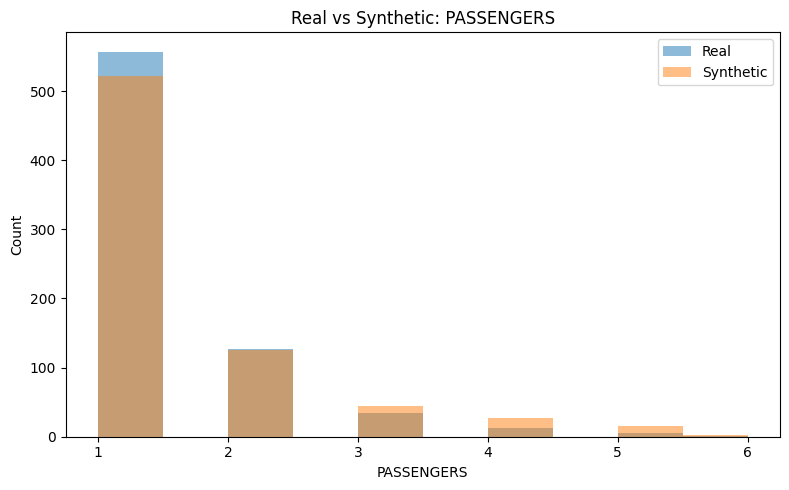

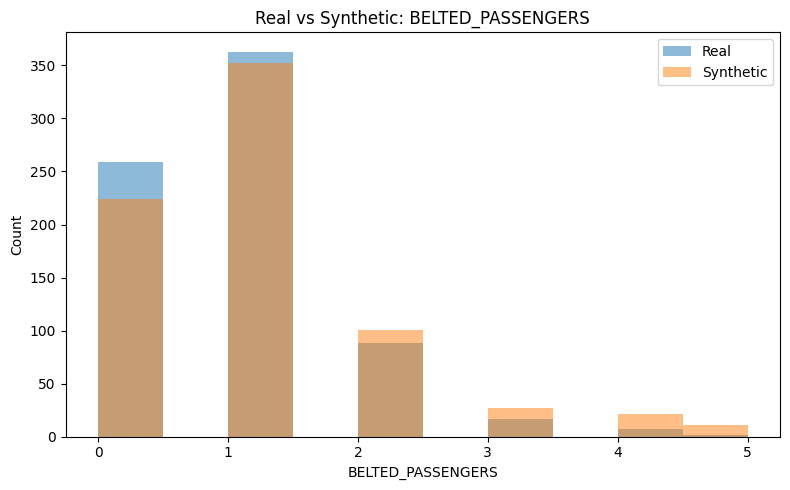

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

categorical_columns = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'ROLLOVER',
    'BODYTYPE',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'
]

numerical_columns = [
    'DVTOTAL',
    'SPEEDLIMIT',
    'PASSENGERS',
    'BELTED_PASSENGERS'
]

for col in categorical_columns:
    counts_df = pd.DataFrame({
        'Real': data[col].value_counts(),
        'Synthetic': synthetic_data[col].value_counts()
    }).fillna(0)

    counts_df.plot(kind='bar', figsize=(8,5))
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Real vs Synthetic: {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for col in numerical_columns:
    plt.figure(figsize=(8,5))
    plt.hist(pd.to_numeric(data[col], errors='coerce').dropna(), alpha=0.5, label='Real')
    plt.hist(pd.to_numeric(synthetic_data[col], errors='coerce').dropna(), alpha=0.5, label='Synthetic')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Real vs Synthetic: {col}')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [37]:
from sdv.evaluation.single_table import get_column_plot

columns = [
    'FUELTYPE',
    'WEATHER',
    'SURFCOND',
    'DVTOTAL',
    'ROLLOVER',
    'SPEEDLIMIT',
    'BODYTYPE',
    'PASSENGERS',
    'BELTED_PASSENGERS',
    'GAD1',
    'AIRBAG_DEPLOYED',
    'FIRE'
]

for col in columns:
    print(f'--- {col} ---')
    fig = get_column_plot(
        real_data=data,
        synthetic_data=synthetic_data,
        column_name=col,
        metadata=metadata
    )
    fig.show()

--- FUELTYPE ---


--- WEATHER ---


--- SURFCOND ---


--- DVTOTAL ---


--- ROLLOVER ---


...

--- PASSENGERS ---


--- BELTED_PASSENGERS ---


--- GAD1 ---


--- AIRBAG_DEPLOYED ---


--- FIRE ---


In [38]:
from sdv.evaluation.single_table import get_column_pair_plot

pairs = [
    ['DVTOTAL', 'AIRBAG_DEPLOYED'],
    ['DVTOTAL', 'ROLLOVER'],
    ['PASSENGERS', 'BELTED_PASSENGERS'],
    ['WEATHER', 'SURFCOND'],
    ['SPEEDLIMIT', 'DVTOTAL'],
    ['BODYTYPE', 'ROLLOVER'],
    ['SURFCOND', 'ROLLOVER'],
    ['DVTOTAL', 'FIRE']
]

for pair in pairs:
    fig = get_column_pair_plot(
        real_data=data,
        synthetic_data=synthetic_data,
        column_names=pair,
        metadata=metadata
    )

    fig.update_layout(
        title=f"Real vs Synthetic: {pair[0]} vs {pair[1]}",
        title_x=0.5,
        width=950,
        height=600,
        template='plotly_white'
    )

    fig.show()

In [39]:
import numpy as np
import pandas as pd

synthetic_data["DVTOTAL"] = pd.to_numeric(synthetic_data["DVTOTAL"], errors="coerce").replace(999, np.nan)
synthetic_data["SPEEDLIMIT"] = pd.to_numeric(synthetic_data["SPEEDLIMIT"], errors="coerce").replace(999, np.nan)

In [40]:
import json
import pandas as pd
import numpy as np

synthetic_data["DVTOTAL"] = pd.to_numeric(synthetic_data["DVTOTAL"], errors="coerce").replace(999, np.nan)
synthetic_data["SPEEDLIMIT"] = pd.to_numeric(synthetic_data["SPEEDLIMIT"], errors="coerce").replace(999, np.nan)

weather_map = {
    0: "Missing",
    1: "Clear",
    2: "Rain",
    3: "Sleet/Hail",
    4: "Snow",
    5: "Smoke/Fog",
    6: "Strong crosswind",
    8: "Cloudy",
    9: "Blowing snow",
    10: "Freezing rain"
}

rollover_map = {
    0: "Unknown",
    1: "No rollover",
    2: "Rollover"
}

surfcond_map = {
    0: "Missing",
    1: "Dry",
    2: "Wet",
    3: "Snow",
    4: "Slush",
    5: "Ice/Frost",
    6: "Water",
    8: "Gravel/Dirt"
}

bodytype_map = {
    1: "Passenger car",
    2: "SUV",
    3: "Pickup/Light truck",
    4: "Van/Minivan"
}

airbag_map = {
    0: "Unknown",
    1: "Deployed",
    2: "Not deployed/Not available"
}

fire_map = {
    0: "Missing",
    1: "No fire",
    2: "Fire",
    9: "Unknown"
}

fueltype_map = {
    1: "Gasoline",
    2: "Gasoline/Ethanol",
    4: "Diesel",
    11: "Gasoline/Lithium electric"
}

gad1_map = {
    "B": "Back/Truck Back",
    "C": "Rear of cab",
    "D": "Back (rear of tractor)",
    "F": "Front",
    "L": "Left Side",
    "N": "Noncollision",
    "R": "Right Side",
    "T": "Top",
    "U": "Undercarriage",
    "V": "Front of cargo area",
    "9": "Unknown"
}

code_system = "https://github.com/scubaduber/Kandidatarbete/blob/main/fhir/CodeSystem/crash-data.json"
patient_identifier_system = "https://scubaduber.github.io/Kandidatarbete/fhir/NamingSystem/synthetic-patient-id"

def get_text(value, mapping):
    if pd.isna(value):
        return "Unknown"
    numeric_value = pd.to_numeric(value, errors="coerce")
    if not pd.isna(numeric_value):
        return mapping.get(int(numeric_value), "Unknown")
    text_value = str(value).strip()
    return mapping.get(text_value, text_value)

def sanitize_code(text):
    return (
        str(text)
        .strip()
        .lower()
        .replace(" ", "-")
        .replace("/", "-")
        .replace("(", "")
        .replace(")", "")
        .replace(",", "")
    )

def make_code(label, code):
    return {
        "coding": [
            {
                "system": code_system,
                "code": code,
                "display": label
            }
        ],
        "text": label
    }

def make_value_codeable(text_value, value_code):
    return {
        "coding": [
            {
                "system": code_system,
                "code": value_code,
                "display": text_value
            }
        ],
        "text": text_value
    }

def add_codeable_observation(entry_list, patient_id, encounter_id, obs_id, label, obs_code, text_value):
    value_code = sanitize_code(text_value)
    entry_list.append(
        {
            "fullUrl": f"urn:uuid:{obs_id}",
            "resource": {
                "resourceType": "Observation",
                "id": obs_id,
                "status": "final",
                "code": make_code(label, obs_code),
                "valueCodeableConcept": make_value_codeable(text_value, value_code),
                "subject": {"reference": f"urn:uuid:{patient_id}"},
                "encounter": {"reference": f"urn:uuid:{encounter_id}"}
            }
        }
    )

def add_quantity_observation(entry_list, patient_id, encounter_id, obs_id, label, obs_code, value, unit=None):
    value_quantity = {"value": None if pd.isna(value) else float(value)}
    if unit is not None:
        value_quantity["unit"] = unit

    entry_list.append(
        {
            "fullUrl": f"urn:uuid:{obs_id}",
            "resource": {
                "resourceType": "Observation",
                "id": obs_id,
                "status": "final",
                "code": make_code(label, obs_code),
                "valueQuantity": value_quantity,
                "subject": {"reference": f"urn:uuid:{patient_id}"},
                "encounter": {"reference": f"urn:uuid:{encounter_id}"}
            }
        }
    )

def add_integer_observation(entry_list, patient_id, encounter_id, obs_id, label, obs_code, value, unknown_codes=None):
    numeric_value = pd.to_numeric(value, errors="coerce")
    if pd.isna(numeric_value):
        final_value = None
    elif unknown_codes is not None and int(numeric_value) in unknown_codes:
        final_value = None
    else:
        final_value = int(numeric_value)

    entry_list.append(
        {
            "fullUrl": f"urn:uuid:{obs_id}",
            "resource": {
                "resourceType": "Observation",
                "id": obs_id,
                "status": "final",
                "code": make_code(label, obs_code),
                "valueInteger": final_value,
                "subject": {"reference": f"urn:uuid:{patient_id}"},
                "encounter": {"reference": f"urn:uuid:{encounter_id}"}
            }
        }
    )

def row_to_fhir_entries(row):
    patient_id = f"patient-{row.name}"
    encounter_id = f"encounter-{row.name}"

    entries = [
        {
            "fullUrl": f"urn:uuid:{patient_id}",
            "resource": {
                "resourceType": "Patient",
                "id": patient_id,
                "identifier": [
                    {
                        "system": patient_identifier_system,
                        "value": patient_id
                    }
                ]
            }
        },
        {
            "fullUrl": f"urn:uuid:{encounter_id}",
            "resource": {
                "resourceType": "Encounter",
                "id": encounter_id,
                "status": "finished",
                "subject": {
                    "reference": f"urn:uuid:{patient_id}"
                }
            }
        }
    ]

    add_quantity_observation(entries, patient_id, encounter_id, f"dvtotal-{row.name}", "Delta-V total", "dvtotal", row["DVTOTAL"], "deltaV")
    add_quantity_observation(entries, patient_id, encounter_id, f"speedlimit-{row.name}", "Speed limit", "speed-limit", row["SPEEDLIMIT"], "mph")

    add_codeable_observation(entries, patient_id, encounter_id, f"weather-{row.name}", "Weather", "weather", get_text(row["WEATHER"], weather_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"rollover-{row.name}", "Rollover", "rollover", get_text(row["ROLLOVER"], rollover_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"surfcond-{row.name}", "Surface condition", "surface-condition", get_text(row["SURFCOND"], surfcond_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"bodytype-{row.name}", "Body type", "body-type", get_text(row["BODYTYPE"], bodytype_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"airbag-{row.name}", "Airbag deployed", "airbag-deployed", get_text(row["AIRBAG_DEPLOYED"], airbag_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"fire-{row.name}", "Fire", "fire", get_text(row["FIRE"], fire_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"fueltype-{row.name}", "Fuel type", "fuel-type", get_text(row["FUELTYPE"], fueltype_map))
    add_codeable_observation(entries, patient_id, encounter_id, f"gad1-{row.name}", "General area of damage", "general-area-of-damage", get_text(row["GAD1"], gad1_map))

    add_integer_observation(
        entries,
        patient_id,
        encounter_id,
        f"passengers-{row.name}",
        "Passengers",
        "passengers",
        row["PASSENGERS"],
        unknown_codes={0}
    )

    add_integer_observation(
        entries,
        patient_id,
        encounter_id,
        f"belted-passengers-{row.name}",
        "Belted passengers",
        "belted-passengers",
        row["BELTED_PASSENGERS"],
        unknown_codes={99}
    )

    provenance_id = f"provenance-{row.name}"
    entries.append(
        {
            "fullUrl": f"urn:uuid:{provenance_id}",
            "resource": {
                "resourceType": "Provenance",
                "id": provenance_id,
                "target": [
                    {"reference": f"urn:uuid:{patient_id}"},
                    {"reference": f"urn:uuid:{encounter_id}"}
                ],
                "recorded": "2026-04-21T10:00:00Z",
                "agent": [
                    {
                        "type": {
                            "text": "author"
                        },
                        "who": {
                            "display": "Synthetic crash data generation pipeline"
                        }
                    }
                ],
                "activity": {
                    "coding": [
                        {
                            "system": code_system,
                            "code": "synthetic-data-generation",
                            "display": "Synthetic data generation"
                        }
                    ],
                    "text": "Synthetic data generation"
                }
            }
        }
    )

    return entries

all_entries = []
for _, row in synthetic_data.iterrows():
    all_entries.extend(row_to_fhir_entries(row))

final_bundle = {
    "resourceType": "Bundle",
    "id": "synthetic-crash-bundle-1",
    "type": "collection",
    "entry": all_entries
}

print(json.dumps(final_bundle["entry"][:15], indent=2))

with open('/content/drive/MyDrive/Colab Notebooks/fhir_final_bundle2.json', 'w') as f:
    json.dump(final_bundle, f, indent=2)

print("Saved final bundle to /content/drive/MyDrive/Colab Notebooks/fhir_final_bundle2.json")
print("Total resources in bundle:", len(final_bundle["entry"]))

[
  {
    "fullUrl": "urn:uuid:patient-0",
    "resource": {
      "resourceType": "Patient",
      "id": "patient-0",
      "identifier": [
        {
          "system": "https://scubaduber.github.io/Kandidatarbete/fhir/NamingSystem/synthetic-patient-id",
          "value": "patient-0"
        }
      ]
    }
  },
  {
    "fullUrl": "urn:uuid:encounter-0",
    "resource": {
      "resourceType": "Encounter",
      "id": "encounter-0",
      "status": "finished",
      "subject": {
        "reference": "urn:uuid:patient-0"
      }
    }
  },
  {
    "fullUrl": "urn:uuid:dvtotal-0",
    "resource": {
      "resourceType": "Observation",
      "id": "dvtotal-0",
      "status": "final",
      "code": {
        "coding": [
          {
            "system": "https://github.com/scubaduber/Kandidatarbete/blob/main/fhir/CodeSystem/crash-data.json",
            "code": "dvtotal",
            "display": "Delta-V total"
          }
        ],
        "text": "Delta-V total"
      },
      "value

In [41]:
print(synthetic_data.columns.tolist())

['FUELTYPE', 'WEATHER', 'SURFCOND', 'VIN', 'DVTOTAL', 'ROLLOVER', 'SPEEDLIMIT', 'BODYTYPE', 'PASSENGERS', 'BELTED_PASSENGERS', 'GAD1', 'AIRBAG_DEPLOYED', 'FIRE']


In [42]:
with open('/content/drive/MyDrive/Colab Notebooks/fhir_final_bundle2.json', 'w') as f:
    json.dump(final_bundle, f, indent=2)

In [43]:
with open('/content/drive/MyDrive/Colab Notebooks/fhir_bundles2.json', 'w') as f:
    json.dump(final_bundle, f, indent=2)

In [44]:
from google.colab import files
files.download("/content/drive/MyDrive/Colab Notebooks/fhir_final_bundle2.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>